In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

class SystemModelParams:
    def __init__(self):
        self.N = 9
        self.M = 1
        self.T = 200
        self.d = 0.5   #diff d's

# 1. DEFINE THE TRIANGULAR ARRAY GEOMETRY
def get_triangular_coords(N=12):      #rectangular configuration
    """
    Returns the (x, y) coordinates for a 6x2 Triangular Lattice.
    Normalized by d (half-wavelength).
    Row 1: x = 0, 1, 2...   at y = +h/2
    Row 2: x = 0.5, 1.5...  at y = -h/2
    """
    # X-coordinates (Effective 1D projection is dense: 0, 0.5, 1.0...)
    # Elements 1,3,5... are at 0, 1, 2
    # Elements 2,4,6... are at 0.5, 1.5, 2.5
    # We Interleave them to match indices 0..11
    x_pos = []
    y_pos = []

    # Vertical spacing for equilateral triangles: sqrt(3)/2 * d
    # We center it around y=0
    y_offset = (np.sqrt(3) / 2) / 2

    for i in range(N):
        if i % 2 == 0:
            # Row 1 (Top): Indices 0, 2, 4... (User labels 1, 3, 5...)
            # x = 0, 1, 2... -> i/2
            x_pos.append(i / 2.0)
            y_pos.append(y_offset)
        else:
            # Row 2 (Bottom): Indices 1, 3, 5... (User labels 2, 4, 6...)
            # x = 0.5, 1.5, 2.5... -> (i-1)/2 + 0.5
            x_pos.append((i - 1) / 2.0 + 0.5)
            y_pos.append(-y_offset)

    return torch.tensor(x_pos), torch.tensor(y_pos)

# 2. UPGRADED MODEL (2D Aware)
class TriangularArrayMUSIC(nn.Module):
    def __init__(self, N: int, T: int, M: int, x_pos, y_pos):
        super().__init__()
        self.N, self.T, self.M = N, T, M

        # Save Geometry buffers
        self.register_buffer('x_pos', x_pos)
        self.register_buffer('y_pos', y_pos)

        self.angels = torch.linspace(-np.pi/2, np.pi/2, 361)

        # Architecture (Big Brain)
        self.input_size = 2 * self.N
        self.hidden_size = 128

        self.rnn = nn.GRU(self.input_size, self.hidden_size, batch_first=True)
        self.fc = nn.Linear(self.hidden_size, self.hidden_size * self.N)
        self.fc1 = nn.Linear(self.angels.shape[0], self.hidden_size)
        self.fc2 = nn.Linear(self.hidden_size, self.hidden_size)
        self.fc3 = nn.Linear(self.hidden_size, self.M)

        self.ReLU = nn.ReLU()
        self.BatchNorm = nn.BatchNorm1d(self.T)

        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)

    def forward(self, X):
        # Data Prep
        X_cat = torch.cat((X.real, X.imag), dim=1) # [B, 2N, T]
        X_feat = X_cat.permute(0, 2, 1)            # [B, T, 2N]
        X_feat = self.BatchNorm(X_feat)

        gru_out, _ = self.rnn(X_feat)
        Rx_feat = gru_out[:, -1, :]

        # FC
        x = self.ReLU(self.fc2(Rx_feat))
        x = self.ReLU(self.fc2(x))
        DOA = self.fc3(x)

        return torch.tanh(DOA) * (np.pi / 2)

# 3. FAST GENERATOR (2D Physics)
def create_2d_batch(batch_size, params, device, snr, x_pos, y_pos):
    # Random Azimuth Angles
    angles = (torch.rand(batch_size, 1, device=device) * (2*np.pi/3)) - (np.pi/3)

#angle swapping throughout the elevation???

    # 2D Phase Calculation
    # We assume Azimuth scan (theta) at Elevation=90 (Horizon)
    # Phase = k * (x * sin(theta))
    # Note: For pure Azimuth scan on planar array, y-offset phase is constant
    # unless we scan elevation too. We include it for completeness.

    # Broadcast shapes: [1, N, 1]
    x_grid = x_pos.view(1, params.N, 1)
    y_grid = y_pos.view(1, params.N, 1) # Unused if elevation is fixed at 0

    # Steering Vector: exp(-j * pi * x_norm * sin(theta))
    phi = -1j * np.pi * x_grid * torch.sin(angles).view(batch_size, 1, 1)
    A = torch.exp(phi)

    # Signal & Noise
    S = (torch.randn(batch_size, 1, params.T, device=device) +
         1j*torch.randn(batch_size, 1, params.T, device=device)) * 0.707

    noise_pwr = 10**(-snr/10.0)
    N = (torch.randn(batch_size, params.N, params.T, device=device) +
         1j*torch.randn(batch_size, params.N, params.T, device=device)) * np.sqrt(noise_pwr/2)

    X = (A @ S) + N
    return X, angles.squeeze()

# 4. TRAINING LOOP
params = SystemModelParams()
params.N = 14  # Back to 12 Elements
params.M = 1
params.T = 200

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training for TRIANGULAR ARRAY on: {device}")

# Generate Geometry
x_cpu, y_cpu = get_triangular_coords(params.N)
x_gpu, y_gpu = x_cpu.to(device), y_cpu.to(device)

print("Antenna X-Positions (Normalized):", x_cpu.numpy())

# Init Model
model = TriangularArrayMUSIC(N=params.N, T=params.T, M=params.M, x_pos=x_gpu, y_pos=y_gpu).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_history = []
print("Starting Training...")

for epoch in range(15):
    model.train()
    running_loss = 0.0
    cur_snr = 50 if epoch < 5 else (30 if epoch < 10 else 10)

    pbar = tqdm(range(50), desc=f"Ep {epoch+1}/15 [SNR={cur_snr}]")

    for _ in pbar:
        optimizer.zero_grad()
        X, Y = create_2d_batch(32, params, device, cur_snr, x_gpu, y_gpu)

        pred = model(X)

        diff = pred.squeeze() - Y
        diff = torch.remainder(diff + np.pi, 2 * np.pi) - np.pi
        loss = torch.mean(diff**2)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({"Err": f"{(np.sqrt(loss.item()) * 180/np.pi):.1f}°"})

    loss_history.append(running_loss/50)

#plt.plot(loss_history)
#plt.title("Triangular Array Training")
#plt.show()


def run_rls_beamforming(target_angle_rad, N=8, d=0.5):
  print(f"\n[RLS] Initializing Adaptive Beamformer for Target: {np.degrees(target_angle_rad):.2f} deg")

  sig2 = 0.01
  alpha = 0.9
  K = 200  # Increased iterations for better plot
  thetaS = target_angle_rad
  thetaI = -60 * np.pi / 180  # Interference angle

  # 2. Desired Signal & Interferer
  T_period = 1E-3
  t = np.arange(K) * T_period / (K - 1)
  S = np.cos(2 * np.pi * t / T_period) # Desired (Pilot)
  I = np.sin(np.pi * t / T_period)     # Interference

  # 3. Steering Vectors
  # vS = exp(1j*(i-1)*2*pi*d*sin(thetaS))
  idx = np.arange(N)
  vS = np.exp(1j * idx * 2 * np.pi * d * np.sin(thetaS))
  vI = np.exp(1j * idx * 2 * np.pi * d * np.sin(thetaI))

  # 4. Received Signal (x) & Noise (n)
  # x = vS.'*S + vI.'*I  (Outer product to create [N, K] matrix)
  x = np.outer(vS, S) + np.outer(vI, I)
  n = (np.random.randn(N, K) + 1j * np.random.randn(N, K)) * np.sqrt(sig2)
  x = x + n

  # 5. Initialization for RLS
  Rxx = np.outer(x[:, 0], x[:, 0].conj()) + 0.1 * np.eye(N)
  Rinv = np.linalg.inv(Rxx)
  alinv = 1.0 / alpha
  w = np.zeros((N, K), dtype=complex)

  # 6. RLS Update Loop
  for jj in range(1, K):
      x_vec = x[:, jj].reshape(-1, 1) # Column vector [N, 1]

      # Rinv = alinv * Rinv - (alinv^2 * Rinv * x * x' * Rinv) / (1 + alinv * x' * Rinv * x)
      num = (alinv**2) * (Rinv @ x_vec @ x_vec.conj().T @ Rinv)
      den = 1 + alinv * (x_vec.conj().T @ Rinv @ x_vec)
      Rinv = alinv * Rinv - num / den

      # Gain vector g
      g = Rinv @ x_vec

      # Update weights
      # w(:,jj) = w(:,jj-1) + g * [S(jj) - x(:,jj)' * w(:,jj-1)]
      prior_w = w[:, jj-1].reshape(-1, 1)
      error = S[jj] - (x_vec.conj().T @ prior_w)

      new_w = prior_w + g * error
      w[:, jj] = new_w.flatten()

  # 7. Final Weights for Plotting
  final_w = w[:, -1]

  # Calculate Array Factor (AF) for plotting
  theta_scan = np.linspace(-np.pi/2, np.pi/2, 360)
  AF = np.zeros_like(theta_scan, dtype=complex)

  for i in range(N):
      # AF = AF + ww(i)'*exp(1j*(i-1)*2*pi*d*sin(theta))
      steering = np.exp(1j * i * 2 * np.pi * d * np.sin(theta_scan))
      AF += final_w[i].conj() * steering

  return theta_scan, AF, final_w

Training for TRIANGULAR ARRAY on: cuda
Antenna X-Positions (Normalized): [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5]
Starting Training...


Ep 15/15 [SNR=10]: 100%|██████████| 50/50 [00:00<00:00, 200.06it/s, Err=1.9°]


In [2]:
torch.save(model.state_dict(), "triangular_music_model_int.pth")
print("Model saved successfully as 'triangular_music_model_int.pth'")

from google.colab import files
try:
    files.download("triangular_music_model_int.pth")
except:
    print("Could not trigger auto-download, check the files tab on the left.")

Model saved successfully as 'triangular_music_model_int.pth'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import torch
!pip install onnxscript
# Assuming 'model' is your trained GRU and 'dummy_input' matches your input shape
torch.onnx.export(model, X, "aoa_model.onnx")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 16.9 MB/s eta 0:00:00


/tmp/ipykernel_857/3945743098.py:4: UserWarning: Exporting a model while it is in training mode. Please ensure that this is intended, as it may lead to different behavior during inference. Calling model.eval() before export is recommended.
  torch.onnx.export(model, X, "aoa_model.onnx")


[torch.onnx] Obtain model graph for `TriangularArrayMUSIC([...]` with `torch.export.export(..., strict=False)`...


/usr/lib/python3.12/contextlib.py:144: UserWarning: The tensor attributes self.rnn._flat_weights[0], self.rnn._flat_weights[1], self.rnn._flat_weights[2], self.rnn._flat_weights[3] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


[torch.onnx] Obtain model graph for `TriangularArrayMUSIC([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.11.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"x"<FLOAT,[32,14,200,2]>
            ),
            outputs=(
                %"mul"<FLOAT,[32,1]>
            ),
            initializers=(
                %"rnn.weight_ih_l0"<FLOAT,[384,28]>{TorchTensor(...)},
                %"rnn.weight_hh_l0"<FLOAT,[384,128]>{TorchTensor(...)},
                %"fc2.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"fc2.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"fc3.weight"<FLOAT,[1,128]>{TorchTensor(...)},
                %"fc3.bias"<FLOAT,[1]>{TorchTensor<FLOAT,[1]>(Parameter containing: tensor([-0.0044], device='cuda:0', requires_grad=True), name='fc3.bias')},
                %"BatchNorm.weight"<FLO

In [8]:
!pip install -U onnx onnx2tf onnx-graphsurgeon ai-edge-litert sng4onnx
import onnx2tf
import tensorflow as tf

onnx_model_path = "aoa_model.onnx"
tf_model_path = "tf_saved_model_dir"
tflite_model_path = "aoa_model.tflite"

print("Converting onnx to tf format...")
onnx2tf.convert(
    input_onnx_file_path=onnx_model_path,
    output_folder_path=tf_model_path,
    copy_onnx_input_output_names_to_tflite=True,
    non_verbose=True
)
print("Converting tf to tflite...")
convertor = tf.lite.TFLiteConverter.from_saved_model(tf_model_path)

convertor.optimizations = [
    tf.lite.Optimize.DEFAULT
]
convertor.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

try:
    tflite_model = convertor.convert()
    with open(tflite_model_path, 'wb') as f:
        f.write(tflite_model)

    print(f"DONE! your microcontroller model: {tflite_model_path}")
except Exception as e:
    print(f"ERROR: {e}")

  Using cached onnx2tf-2.4.2-py3-none-any.whl.metadata (223 kB)
  Using cached sng4onnx-2.0.1-py3-none-any.whl.metadata (4.6 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached onnx-1.20.1-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.4 kB)
  Using cached onnxruntime-1.24.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.1 kB)
  Using cached opencv_python-4.11.0.86-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached onnxsim_prebuilt-0.4.39.post2-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (7.3 kB)
  Using cached onnxoptimizer-0.4.2-cp312-abi3-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (3.1 kB)
  Using cached onnxscript-0.6.2-py3-none-any.whl.metadata (13 kB)
  Using cached ai_edge_litert-2.1.2-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (2.1 kB)
  Using cached sne4onnx-2.0.1-py3-none-any.whl

In [9]:
with open("aoa_model.tflite", "rb") as f:
    tflite_content = f.read()

hex_lines = [", ".join([f"0x{b:02x}" for b in tflite_content[i:i+12]])
             for i in range(0, len(tflite_content), 12)]
hex_array = ",\n  ".join(hex_lines)

with open("model_data.h", "w") as f:
  f.write("//Auto generated tflite model for teensy 4.1")
  f.write("//Team Abhyuday, IREC '26\n\n")
  f.write("alignas(8) const unsigned char g_model[] = {\n  ")
  f.write(hex_array)
  f.write("\n};\n\n")
  f.write(f"const int g_model_len = {len(tflite_content)};\n")

print("DOne! model_data.h created")
print(f"Model size: {len(tflite_content)/1024: .2f} KB")

DOne! model_data.h created
Model size:  3318.38 KB


Evaluating on 100 samples at SNR=10dB...
Final RMSE Accuracy: 1.81 degrees

--- Random Examples ---
Truth: -50.19° | Pred: -53.17° | Error: 2.98°
Truth:  -4.44° | Pred:  -2.92° | Error: 1.52°
Truth:  38.97° | Pred:  37.33° | Error: 1.65°
Truth:  39.36° | Pred:  38.79° | Error: 0.57°
Truth:  16.79° | Pred:  15.78° | Error: 1.02°
Truth:  -9.75° | Pred: -10.33° | Error: 0.58°
Truth: -15.29° | Pred: -13.58° | Error: 1.72°
Truth: -42.23° | Pred: -44.11° | Error: 1.87°
Truth:   8.16° | Pred:  12.01° | Error: 3.85°
Truth:  -7.15° | Pred:  -7.66° | Error: 0.51°
Truth: -11.29° | Pred: -12.16° | Error: 0.86°
Truth: -31.32° | Pred: -27.61° | Error: 3.71°
Truth:  49.40° | Pred:  47.50° | Error: 1.90°
Truth:  47.41° | Pred:  48.24° | Error: 0.83°
Truth: -58.51° | Pred: -60.37° | Error: 1.86°
Truth:  33.43° | Pred:  33.06° | Error: 0.37°
Truth: -22.87° | Pred: -23.87° | Error: 1.01°
Truth: -50.93° | Pred: -53.99° | Error: 3.06°
Truth: -57.09° | Pred: -60.92° | Error: 3.83°
Truth:  52.48° | Pred:  54

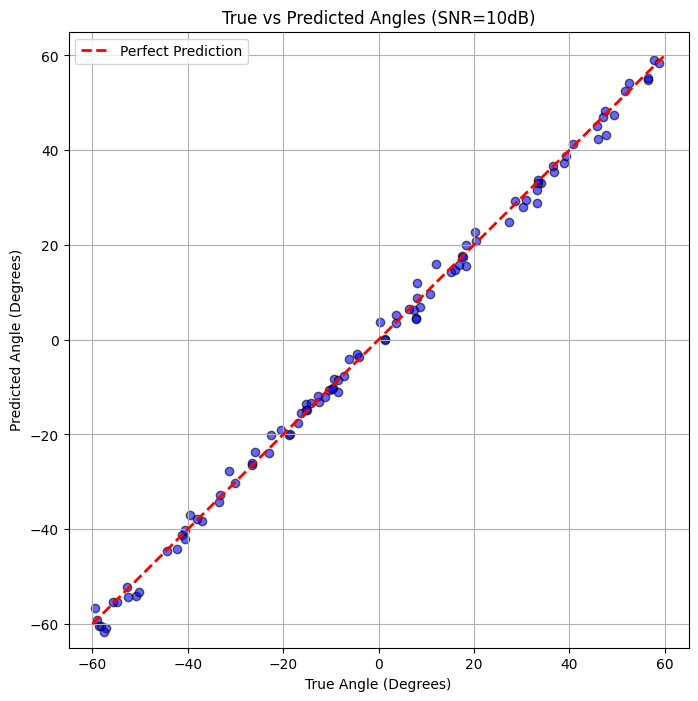

In [10]:
import matplotlib.pyplot as plt

#EVALUATION CONFIGURATION
TEST_SAMPLES = 100
TEST_SNR = 10

model.eval()

print(f"Evaluating on {TEST_SAMPLES} samples at SNR={TEST_SNR}dB...")

# Generate Test Data
# We use a larger batch size for statistics
with torch.no_grad():
    X_test, Y_test = create_2d_batch(TEST_SAMPLES, params, device, TEST_SNR, x_gpu, y_gpu)

    # Predict
    predictions = model(X_test)

# Convert to Degrees for Human Readability
Y_deg = Y_test.cpu().numpy() * (180 / np.pi)
Pred_deg = predictions.squeeze().cpu().numpy() * (180 / np.pi)

# Calculate Metrics
errors = np.abs(Y_deg - Pred_deg)
# Handle periodicity (e.g., error between -179 and +179 is 2 degrees, not 358)
errors = np.minimum(errors, 360 - errors)
rmse = np.sqrt(np.mean(errors**2))

print(f"Final RMSE Accuracy: {rmse:.2f} degrees")

# Show 5 Random Examples
print("\n--- Random Examples ---")
for i in np.random.choice(TEST_SAMPLES, 20, replace=False):
    print(f"Truth: {Y_deg[i]:6.2f}° | Pred: {Pred_deg[i]:6.2f}° | Error: {errors[i]:.2f}°")

# Visualization
plt.figure(figsize=(8, 8))
plt.scatter(Y_deg, Pred_deg, alpha=0.6, color='blue', edgecolors='k')
plt.plot([-60, 60], [-60, 60], 'r--', linewidth=2, label="Perfect Prediction")
plt.title(f"True vs Predicted Angles (SNR={TEST_SNR}dB)")
plt.xlabel("True Angle (Degrees)")
plt.ylabel("Predicted Angle (Degrees)")
plt.grid(True)
plt.legend()
plt.xlim(-65, 65)
plt.ylim(-65, 65)
plt.show()

SUCCESSFULLY LOADED: triangular_music_model_int.pth
1. ACTUAL Drone Position:   -36.35°
2. AI PREDICTED Position:   -36.54°

[RLS] Initializing Adaptive Beamformer for Target: -36.54 deg


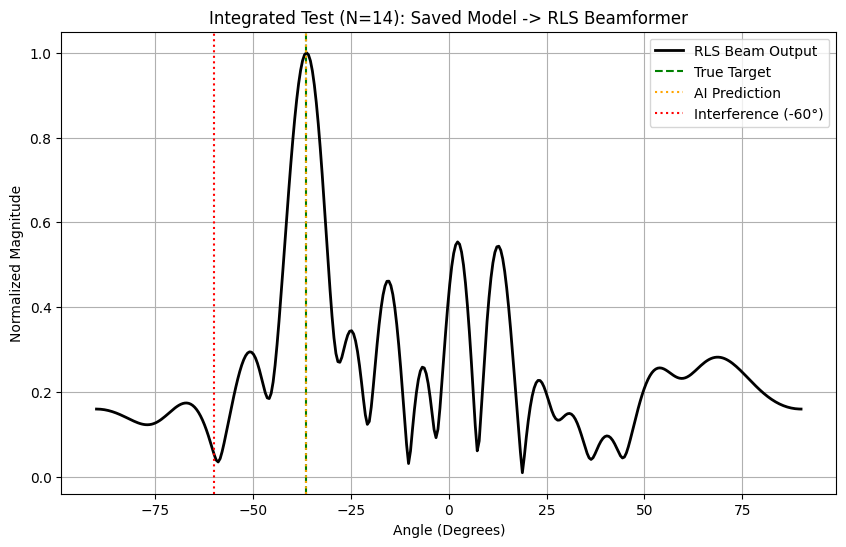

array([ 0.11960781-0.12215892j,  0.00710919-0.11175293j,
       -0.03692921+0.00643627j,  0.06818092+0.0807429j ,
        0.02820602-0.05868478j, -0.00710006-0.00837745j,
       -0.02351018+0.07183889j,  0.09707267-0.05004038j,
       -0.04053942-0.08732831j, -0.02052878-0.01083388j,
        0.09595764+0.01575232j,  0.03850006-0.04010776j,
       -0.01738653+0.09231756j,  0.10253654+0.07856505j])

In [11]:
params = SystemModelParams()
device = torch.device("cpu")

params.N = 14

x_cpu, y_cpu = get_triangular_coords(params.N)

model = TriangularArrayMUSIC(params.N, params.T, params.M, x_cpu, y_cpu).to(device)
model_filename = "triangular_music_model_int.pth"

try:
    model.load_state_dict(torch.load(model_filename, map_location=device))
    print(f"SUCCESSFULLY LOADED: {model_filename}")
except FileNotFoundError:
    print(f"ERROR: Could not find '{model_filename}'. Please upload it to Colab Files.")
    exit()

model.eval()

# Generating test signal
true_angle = np.random.uniform(-45, 45)
print(f"1. ACTUAL Drone Position:   {true_angle:.2f}°")

# Create synthetic input for this angle
theta_fixed = torch.tensor([np.radians(true_angle)], device=device)
x_grid = x_cpu.view(1, params.N, 1)

# Ensure phi is complex64
phi_components_real = -1.0 * torch.tensor(np.pi, device=device, dtype=torch.float32) * x_grid * torch.sin(theta_fixed).view(1, 1, 1)
phi = torch.complex(torch.zeros_like(phi_components_real), phi_components_real).to(torch.complex64)
A = torch.exp(phi)

# Ensure S_sig is complex64
S_sig_real = torch.randn(1, 1, params.T, device=device, dtype=torch.float32)
S_sig_imag = torch.randn(1, 1, params.T, device=device, dtype=torch.float32)
S_sig = (S_sig_real + 1j * S_sig_imag).to(torch.complex64)

X_input = (A @ S_sig)

# AoA estimation
with torch.no_grad():
    pred_rad = model(X_input).item()
print(f"2. AI PREDICTED Position:   {np.degrees(pred_rad):.2f}°")

# Performing Beamforming
theta_axis, af_response, weights = run_rls_beamforming(pred_rad, N=params.N)

# Plotting
norm_af = np.abs(af_response) / np.max(np.abs(af_response))

plt.figure(figsize=(10, 6))
plt.plot(np.degrees(theta_axis), norm_af, 'k', linewidth=2, label='RLS Beam Output')
plt.axvline(x=true_angle, color='g', linestyle='--', label='True Target')
plt.axvline(x=np.degrees(pred_rad), color='orange', linestyle=':', label='AI Prediction')
plt.axvline(x=-60, color='r', linestyle=':', label='Interference (-60°)')

plt.title(f'Integrated Test (N={params.N}): Saved Model -> RLS Beamformer')
plt.xlabel('Angle (Degrees)')
plt.ylabel('Normalized Magnitude')
plt.legend()
plt.grid(True)
plt.show()
weights